In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns
import tqdm

from networks import InvariantValueNet, ValueNet, sinkhorn
from utils import get_batches

print(jax.devices())


[CudaDevice(id=0)]


In [2]:
random_key = jax.random.PRNGKey(42)

batch_size = 256
width = 32

out_size = 1 # or 1 for continuous
qtype = "flip_id_float" # "flip_id_fixed", "flip_id_float", "learnable_float", "sinkhorn"

n_epochs = 50
start_beta = 10.0 #1e-2
end_beta = 10.0 #1e-2

sink_temp_start = 1.0
sink_temp_end = 1.0
sink_iter = 15

value_net_equiv = InvariantValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    body_depth=2,
    body_width=width,
    embed_dim=width,
    activation=jax.nn.gelu,
    out_size=out_size,
    name="equiv",
    qtype=qtype,
)


value_net_nosym = ValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    body_depth=2,
    body_width=width,
    embed_dim=width,
    activation=jax.nn.gelu,
    avg_symmetries=False,
    out_size=out_size,
    name="nosym",
)

value_net_sym = ValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    body_depth=2,
    body_width=width,
    embed_dim=width,
    activation=jax.nn.gelu,
    avg_symmetries=True,
    out_size=out_size,
    name="sym",
)


In [3]:
opt = optax.adam(1e-3)

value_nets = [value_net_equiv, value_net_sym, value_net_nosym]
opts = []
for value_net in value_nets:
    params = eqx.filter(value_net, eqx.is_inexact_array)
    opts.append(opt.init(params))

_train_boards = np.load("data/train_boards.npy")
_train_values = np.load("data/train_values.npy")
_test_boards = np.load("data/test_boards.npy")
_test_values = np.load("data/test_values.npy")


n_train = _train_boards.shape[0]
n_sample = int(n_train * 1.0)
random_key, subkey = jax.random.split(random_key)
indices = jax.random.choice(subkey, n_train, shape=(n_sample,), replace=False)
train_boards = jnp.stack(
    [_train_boards[indices] == 1, _train_boards[indices] == 2], axis=-1
).astype(jnp.float32)
train_values = jnp.asarray(_train_values[indices], dtype=jnp.float32)
test_boards = jnp.stack([_test_boards == 1, _test_boards == 2], axis=-1).astype(
    jnp.float32
)
test_values = jnp.asarray(_test_values, dtype=jnp.float32)


@eqx.filter_jit
def do_epoch(
    random_key,
    value_net,
    opt_state,
    obs,
    values,
    opt,
    batch_size,
    epochid,
    alpha=0.0,
    interm_alpha=0.0,
):
    params, static = eqx.partition(value_net, eqx.is_inexact_array)

    data = get_batches((obs, values), random_key, batch_size, drop_last=True)
    
    global_step = epochid * len(data[0])
    total_step = n_epochs * len(data[0])

    k = 0
    def body_fn(carry, x):
        params, opt_state, k = carry
        obs, values = x
        value_net = eqx.combine(params, static)

        beta = start_beta + (end_beta - start_beta) * ((global_step + k) / total_step)
        beta = jnp.asarray(beta, dtype=jnp.float32)
        sink_temp = sink_temp_start + (sink_temp_end - sink_temp_start) * ((global_step + k) / total_step)
        sink_temp = jnp.asarray(sink_temp, dtype=jnp.float32)
    
        (_, metrics), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
            value_net, obs, values, alpha, interm_alpha, beta, sink_temp, sink_iter
        )
        updates, opt_state = opt.update(grads, opt_state)
        value_net = eqx.apply_updates(value_net, updates)
        params = eqx.filter(value_net, eqx.is_inexact_array)
        return (params, opt_state, k + 1), (metrics)

    (params, opt_state, _), metrics = jax.lax.scan(body_fn, (params, opt_state, k), data)
    value_net = eqx.combine(params, static)
    return value_net, opt_state, metrics


def cross_entropy_loss(logits, labels):
    """
    logits: (N, 3) float array
    labels: (N,) int array with values in {-1, 0, 1}
    """
    # 1. Convert to one-hot encoding
    # num_classes=3 matches the second dimension of your logits
    target_one_hot = jax.nn.one_hot(labels, num_classes=3)
    
    # 2. Compute log softmax for stability
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    
    # 3. Calculate mean cross entropy: -sum(target * log_prob)
    loss = -jnp.sum(target_one_hot * log_probs) / logits.shape[0]
    return loss

@eqx.filter_jit
def loss_fn(value_net, obs, values, alpha=0.0, interm_alpha=0.0, beta=1.0, sink_temp=1.0, sink_iter=15):
    preds = jax.vmap(value_net.forward, in_axes=(0, None, None))(
        obs, sink_temp, sink_iter
    )
    if value_net.body.__class__.__name__ == "EquivariantMLP":
        qs_idloss = 0.0
        q = value_net.body._q
        if value_net.qtype == "sinkhorn":
            A = 0.5 * (q + q.T)
            q = sinkhorn(q / sink_temp, n_iters=sink_iter)
        qs_idloss = jnp.sum((jnp.eye(q.shape[0], dtype=q.dtype) - (q @ q))**2) / (width**2) # how close Q@Q is to identity
        # for l in value_net.body.layers:
        #     q = l.q
        #     qqidloss +=  jnp.sum((jnp.eye(q.shape[0], dtype=q.dtype) - (q @ q))**2) / (width**2)
        q_idloss = jnp.sum((jnp.eye(q.shape[0], dtype=q.dtype) - (q))**2) / (width**2) # how close Q is to identity on its own
    else:
        qs_idloss = 0.0
        q_idloss = 0.0

    if preds.ndim == 1:
        # shape N
        loss_l2 = jnp.mean((preds - values) ** 2)
        loss_l1 = jnp.mean(jnp.abs(preds - values))
        beta_huber = 0.2
        loss_huber = jnp.mean(
            jnp.where(
                jnp.abs(preds - values) < beta_huber,
                0.5 * (preds - values) ** 2 / beta_huber,
                jnp.abs(preds - values) - 0.5 * beta_huber,
            )
        )
 
        
        loss_main = loss_huber
        
        # unused for [N,]
        loss_ce = 0.0
        accuracy = 0.0
        
    else:
        # shape N, 3
        shifted_labels = values + 1
        loss_ce = cross_entropy_loss(preds, shifted_labels)
        
        loss_main = loss_ce

        accuracy = jnp.mean(jnp.argmax(preds, axis=-1) == shifted_labels)
        
        # unused for [N,3]
        loss_l2 = 0.0
        loss_l1 = 0.0
    
    
    
    loss = loss_main + beta * qs_idloss

    return loss, {
        "value_loss": loss_main,
        "qs_idloss": qs_idloss,
        "q_idloss": q_idloss,
        "l2_loss": loss_l2,
        "l1_loss": loss_l1,
        "ce_loss": loss_ce,
        "accuracy": accuracy,
    }


In [4]:
rows = []
Qs = []
k = 0

def append_metrics_to_rows(rows, eval_lossdict, k, model_name="noname"):
    for key, value in eval_lossdict.items():
        row = {
            "value": float(value),
            "step": k,
            "metric": f"{model_name}_{key}",
        }
        rows.append(row)
    return rows


for value_net in value_nets:
    eval_loss_sym, eval_dict = loss_fn(value_net, test_boards, test_values)
    rows = append_metrics_to_rows(rows, eval_dict, k, value_net.name)

    if value_net.name == "equiv":
        q = value_net.body._q
        if value_net.qtype == "sinkhorn":
            A = 0.5 * (q + q.T)
            q = sinkhorn(A / sink_temp_start, n_iters=sink_iter)
        
        Qs.append(q)

    if value_net.name == "nosym":
        value_net = eqx.combine(
            eqx.filter(value_net, eqx.is_inexact_array),
            eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
        )
        rows = append_metrics_to_rows(rows, eval_dict, k, "nosym_evalsym")

2026-04-22 11:25:48.151421: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-22 11:25:48.151472: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [5]:
for epoch in tqdm.trange(n_epochs):
    random_key, subkey = jax.random.split(random_key)

    new_value_nets, new_opts = [], []
    for value_net, opt_state in zip(value_nets, opts):
        value_net, opt_state, metrics = do_epoch(
            subkey,
            value_net,
            opt_state,
            train_boards,
            train_values,
            opt,
            batch_size,
            jnp.asarray(epoch, dtype=jnp.int32),
        )
        new_value_nets.append(value_net)
        new_opts.append(opt_state)
        
        if value_net.name == "equiv":
            q = value_net.body._q
            if value_net.qtype == "sinkhorn":
                A = 0.5 * (q + q.T)
                sink_temp = sink_temp_start + (sink_temp_end - sink_temp_start) * (epoch / n_epochs)
                q = sinkhorn(A / sink_temp_start, n_iters=sink_iter)
            Qs.append(q)

    value_nets = new_value_nets
    opts = new_opts

    n_updates = len(metrics["value_loss"])
    k += n_updates

    for value_net in value_nets:
        eval_loss_sym, eval_dict = loss_fn(value_net, test_boards, test_values)
        rows = append_metrics_to_rows(rows, eval_dict, k, value_net.name)

        if value_net.name == "nosym":
            value_net = eqx.combine(
                eqx.filter(value_net, eqx.is_inexact_array),
                eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
            )
            eval_loss_sym, eval_dict = loss_fn(value_net, test_boards, test_values)
            rows = append_metrics_to_rows(rows, eval_dict, k, "nosym_evalsym")


  0%|          | 0/50 [00:00<?, ?it/s]2026-04-22 11:25:50.862511: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-22 11:25:50.862535: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-22 11:25:50.862544: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-22 11:25:50.862

204
204
204
204
204
204
204
['equiv_accuracy', 'sym_accuracy', 'nosym_accuracy', 'nosym_evalsym_accuracy']


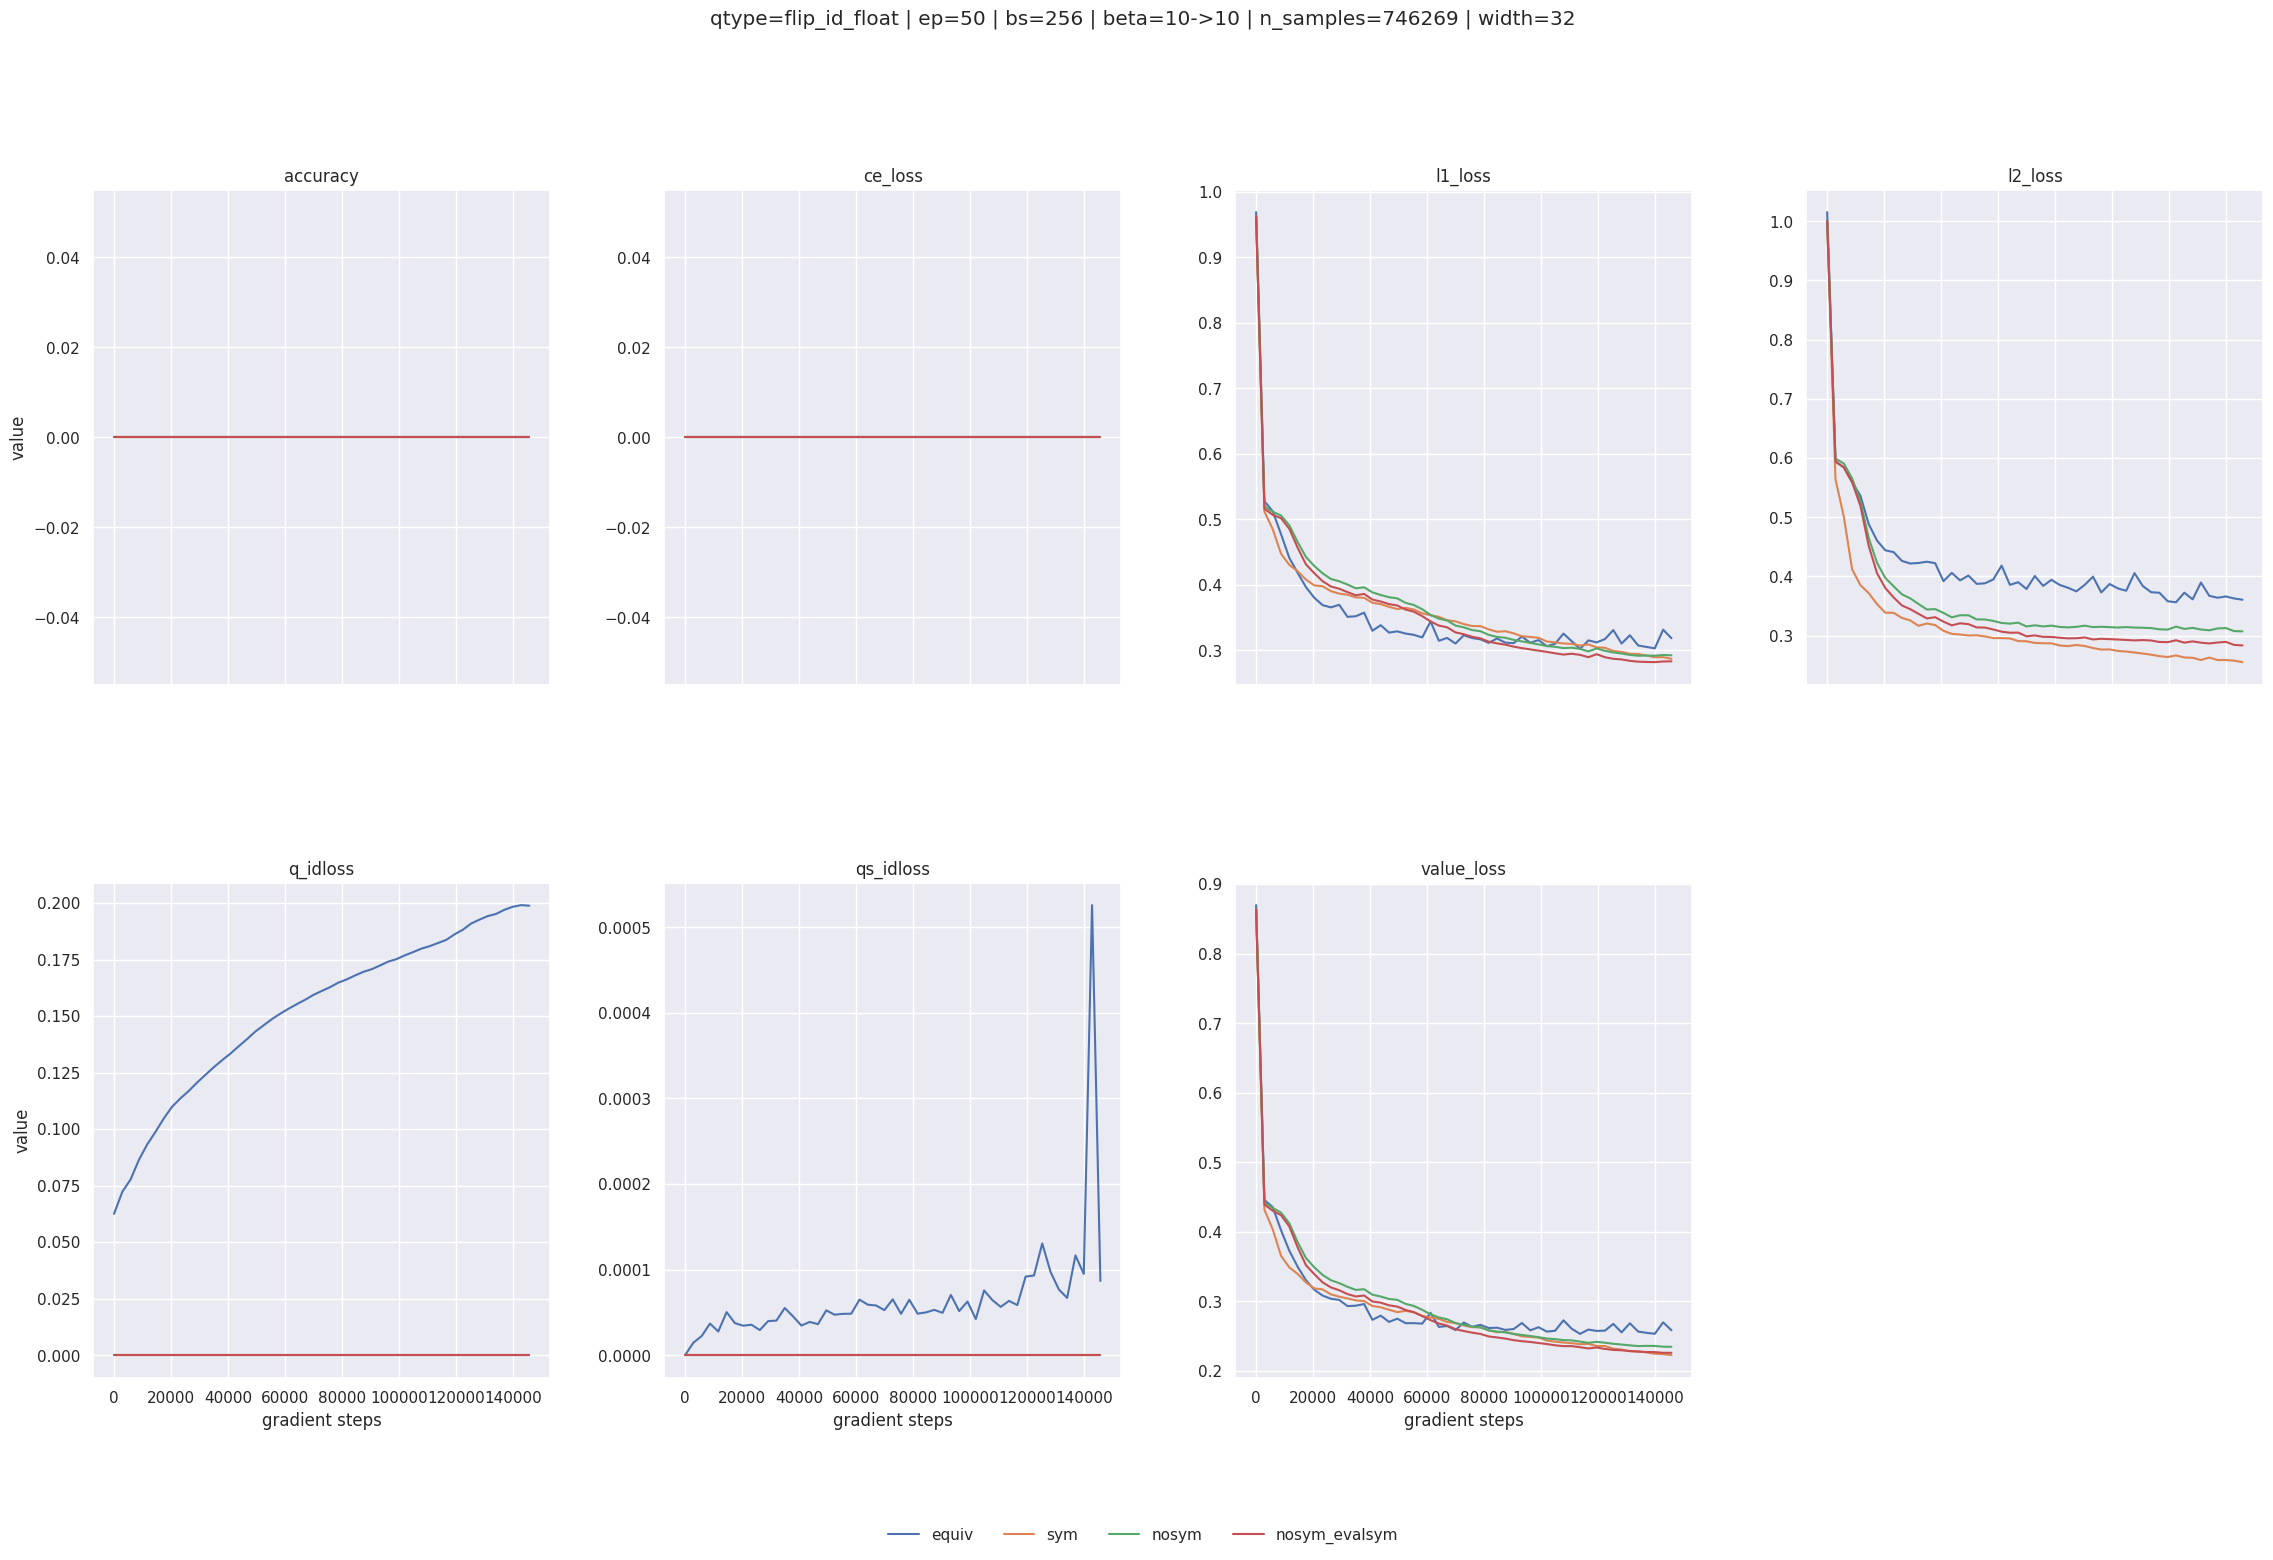

In [6]:
df = pd.DataFrame(rows)
metric_keys = eval_dict.keys()
sns.set_theme()
plot_df_all = df
# plot_df_all = df[df.metric.str.contains("eval")].copy()
# plot_df_all.loc[:, "metric"] = plot_df_all["metric"].str.replace(r"^eval_", "", regex=True)

nrows, ncols = 2, 4
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(28, 18),
    sharex=True,
    sharey=False,
)

global_info = (
    f"qtype={qtype} | ep={n_epochs} | bs={batch_size} | "
    f"beta={start_beta:g}->{end_beta:g} | n_samples={n_sample} | width={width}"
)
fig.suptitle(global_info, y=0.98)
axes = axes.ravel()

max_plots = nrows * ncols
metric_keys = list(metric_keys)
n_plots = min(len(metric_keys), max_plots)
first_metricname = metric_keys[0] if metric_keys else None


for i in range(n_plots):
    metricname = metric_keys[i]
    ax = axes[i]

    plot_df = plot_df_all[plot_df_all.metric.str.endswith(metricname)]
    print(len(plot_df))
    sns.lineplot(
        data=plot_df,
        x="step",
        y="value",
        hue="metric",
        ax=ax,
        legend=(i == 0),
    )

    ax.set_title(metricname)
    # ax.set_yscale("log")

    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("gradient steps")
    else:
        ax.set_xlabel("")

    if i % ncols != 0:
        ax.set_ylabel("")

    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()


    # ax.set_ylim(0, 1)
    
for j in range(n_plots, max_plots):
    fig.delaxes(axes[j])
    
legend_labels_short = []
metric_suffix = f"_{first_metricname}" if first_metricname else None
for lab in legend_labels:
    if metric_suffix and lab.endswith(metric_suffix):
        lab = lab[: -len(metric_suffix)]
    legend_labels_short.append(lab)

print(legend_labels)

if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels_short,
        loc="lower center",
        ncol=min(len(legend_labels), 6),
        frameon=False,
        bbox_to_anchor=(0.5, 0.12),
    )

fig.subplots_adjust(bottom=0.22, wspace=0.25, hspace=0.4)


import datetime
def _fmt(x):
    try:
        return f"{float(x):g}"
    except Exception:
        return str(x)

run_label = (
    f"{qtype}"
    f"_ep{n_epochs}"
    f"_bs{batch_size}"
    f"_b{_fmt(start_beta)}-{_fmt(end_beta)}"
    f"_ns{n_sample}"
    f"_w{width}"
)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
fig.savefig(f"plots/{run_label}_{timestamp}.png", dpi=300)

/tmp/ipykernel_53534/3174550530.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.90, 0.95])


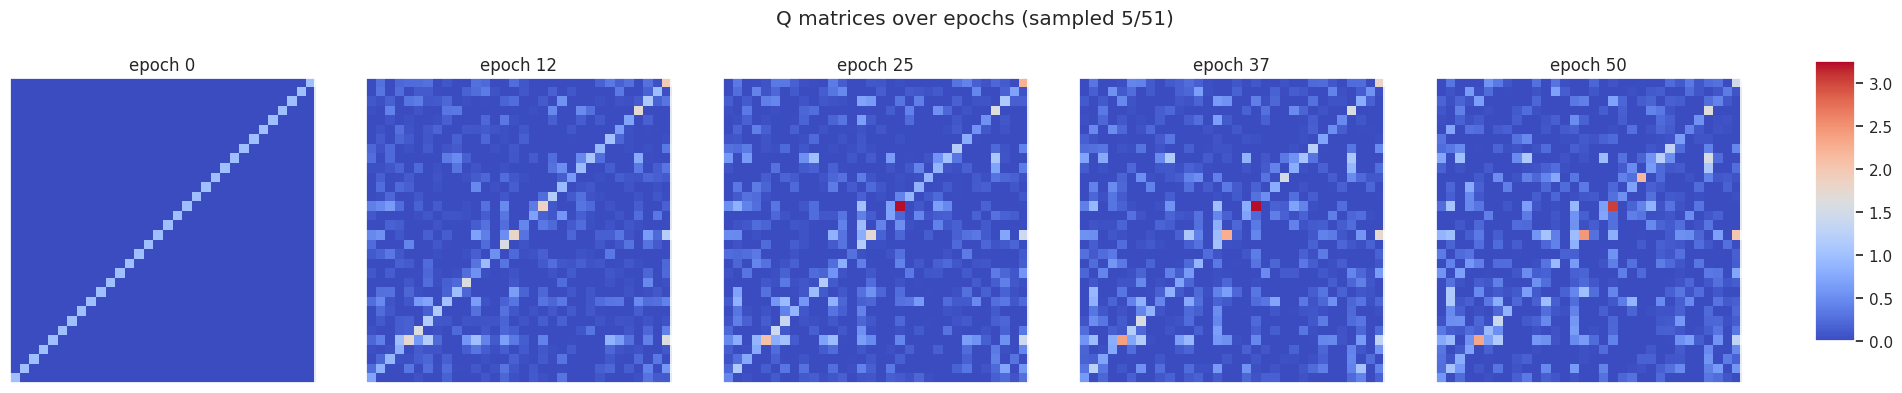

In [7]:
# Plot the Q matrices along the epochs
import numpy as np
import matplotlib.pyplot as plt

if len(Qs) == 0:
    raise ValueError("Qs is empty. Make sure the training loop appends `value_net.body._q` each epoch.")

Qs_np = [np.asarray(Q) for Q in Qs]
T = len(Qs_np)

ncols = 5
n_show = min(T, 5)
epoch_ids = np.unique(np.linspace(0, T - 1, num=n_show, dtype=int))

nrows = int(np.ceil(len(epoch_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

# consistent color scale across epochs
absmax = max(float(np.max(np.abs(Q))) for Q in Qs_np)
absmin = min(float(np.min(np.abs(Q))) for Q in Qs_np)
# absmax = absmax if absmax > 0 else 1.0

im = None
for k, epoch in enumerate(epoch_ids):
    r, c = divmod(k, ncols)
    ax = axes[r, c]
    im = ax.imshow(Qs_np[epoch], cmap="coolwarm", vmin=absmin, vmax=absmax)
    ax.set_title(f"epoch {epoch}")
    ax.set_xticks([])
    ax.set_yticks([])

# delete unused axes
for k in range(len(epoch_ids), nrows * ncols):
    r, c = divmod(k, ncols)
    fig.delaxes(axes[r, c])

# Put the colorbar in its own axis to the right
fig.subplots_adjust(right=0.90)
if im is not None:
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cax)

fig.suptitle(f"Q matrices over epochs (sampled {len(epoch_ids)}/{T})", y=0.98)
fig.tight_layout(rect=[0, 0, 0.90, 0.95])

fig.savefig(f"plots/{run_label}_{timestamp}_q.png", dpi=300)